<a href="https://colab.research.google.com/github/segenie/bigdata/blob/main/2254816(04).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
!pip install mmh3 bitarray

In [18]:
!pip install openpyxl

In [29]:
import pandas as pd

# CSV 파일 읽기
df = pd.read_csv('/content/Online Retail.csv', encoding='ISO-8859-1')

# 데이터 확인
print(df.head())

# 컬럼 확인
print(df.columns)

# 전체 레코드 수
print("전체 데이터 수:", len(df))

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

       InvoiceDate  UnitPrice  CustomerID         Country  
0  2010-12-01 8:26       2.55     17850.0  United Kingdom  
1  2010-12-01 8:26       3.39     17850.0  United Kingdom  
2  2010-12-01 8:26       2.75     17850.0  United Kingdom  
3  2010-12-01 8:26       3.39     17850.0  United Kingdom  
4  2010-12-01 8:26       3.39     17850.0  United Kingdom  
Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')
전체 데이터 수: 541909


In [30]:
# 결측값 제거
df = df.dropna(subset=['StockCode'])

# 문자열 변환
stream_data = df['StockCode'].astype(str)

print(stream_data.head())

0    85123A
1     71053
2    84406B
3    84029G
4    84029E
Name: StockCode, dtype: object


In [31]:
import mmh3
from bitarray import bitarray

class BloomFilter:
    def __init__(self, size, hash_count):

        self.size = size
        self.hash_count = hash_count

        self.bit_array = bitarray(size)
        self.bit_array.setall(0)

    def add(self, item):

        for i in range(self.hash_count):

            index = mmh3.hash(str(item), i) % self.size
            self.bit_array[index] = 1

    def check(self, item):

        for i in range(self.hash_count):

            index = mmh3.hash(str(item), i) % self.size

            if self.bit_array[index] == 0:
                return False

        return True

In [32]:
import time
import sys

# 파라미터 설정
bf_size = 50000
hash_count = 5

bf = BloomFilter(bf_size, hash_count)

# Ground Truth
real_set = set()

false_positive = 0
true_negative = 0

start_time = time.time()

for item in stream_data:

    # Bloom Filter 검사
    bf_result = bf.check(item)

    # 실제 존재 여부
    actual_result = item in real_set

    # False Positive 계산
    if bf_result and not actual_result:
        false_positive += 1

    # True Negative 계산
    if not bf_result and not actual_result:
        true_negative += 1

    # 데이터 추가
    bf.add(item)
    real_set.add(item)

end_time = time.time()

# False Positive Rate
fpr = false_positive / (false_positive + true_negative)

print("===== Bloom Filter 결과 =====")
print("False Positive:", false_positive)
print("True Negative:", true_negative)
print("False Positive Rate:", round(fpr, 6))

print("처리 시간:", round(end_time - start_time, 4), "초")

print("Bloom Filter 메모리:",
      sys.getsizeof(bf.bit_array), "bytes")

===== Bloom Filter 결과 =====
False Positive: 7
True Negative: 4063
False Positive Rate: 0.00172
처리 시간: 2.3317 초
Bloom Filter 메모리: 6330 bytes


In [33]:
import numpy as np

class CountMinSketch:

    def __init__(self, width, depth):

        self.width = width
        self.depth = depth

        self.table = np.zeros((depth, width))

    def add(self, item):

        for i in range(self.depth):

            index = mmh3.hash(str(item), i) % self.width
            self.table[i][index] += 1

    def estimate(self, item):

        estimates = []

        for i in range(self.depth):

            index = mmh3.hash(str(item), i) % self.width
            estimates.append(self.table[i][index])

        return min(estimates)

In [34]:
import collections

# 파라미터 설정
width = 5000
depth = 5

cms = CountMinSketch(width, depth)

# Ground Truth
real_freq = collections.defaultdict(int)

start_time = time.time()

# 스트림 처리
for item in stream_data:

    cms.add(item)
    real_freq[item] += 1

end_time = time.time()

# 오차 계산
errors = []

for item in real_freq.keys():

    estimated = cms.estimate(item)
    actual = real_freq[item]

    relative_error = abs(estimated - actual) / actual
    errors.append(relative_error)

average_error = sum(errors) / len(errors)

print("===== Count-Min Sketch 결과 =====")

print("평균 상대 오차:",
      round(average_error, 6))

print("처리 시간:",
      round(end_time - start_time, 4), "초")

print("Count-Min Sketch 메모리:",
      cms.table.nbytes, "bytes")

===== Count-Min Sketch 결과 =====
평균 상대 오차: 0.101529
처리 시간: 3.4505 초
Count-Min Sketch 메모리: 200000 bytes


In [35]:
results = []

sizes = [10000, 50000, 100000]

for size in sizes:

    bf = BloomFilter(size, 5)

    real_set = set()

    false_positive = 0
    true_negative = 0

    start = time.time()

    for item in stream_data:

        bf_result = bf.check(item)
        actual_result = item in real_set

        if bf_result and not actual_result:
            false_positive += 1

        if not bf_result and not actual_result:
            true_negative += 1

        bf.add(item)
        real_set.add(item)

    end = time.time()

    fpr = false_positive / (false_positive + true_negative)

    results.append([
        size,
        fpr,
        end - start,
        sys.getsizeof(bf.bit_array)
    ])

# 결과 출력
for r in results:

    print("Bit Array Size:", r[0])
    print("False Positive Rate:", round(r[1], 6))
    print("처리 시간:", round(r[2], 4))
    print("메모리:", r[3], "bytes")
    print()

Bit Array Size: 10000
False Positive Rate: 0.159459
처리 시간: 2.7608
메모리: 1330 bytes

Bit Array Size: 50000
False Positive Rate: 0.00172
처리 시간: 1.8422
메모리: 6330 bytes

Bit Array Size: 100000
False Positive Rate: 0.0
처리 시간: 1.8103
메모리: 12580 bytes



In [36]:
results_cms = []

widths = [1000, 5000, 10000]

for width in widths:

    cms = CountMinSketch(width, 5)

    real_freq = collections.defaultdict(int)

    start = time.time()

    for item in stream_data:

        cms.add(item)
        real_freq[item] += 1

    end = time.time()

    errors = []

    for item in real_freq.keys():

        estimated = cms.estimate(item)
        actual = real_freq[item]

        error = abs(estimated - actual) / actual
        errors.append(error)

    avg_error = sum(errors) / len(errors)

    results_cms.append([
        width,
        avg_error,
        end - start,
        cms.table.nbytes
    ])

# 결과 출력
for r in results_cms:

    print("Width:", r[0])
    print("평균 상대 오차:", round(r[1], 6))
    print("처리 시간:", round(r[2], 4))
    print("메모리:", r[3], "bytes")
    print()

Width: 1000
평균 상대 오차: 13.626347
처리 시간: 3.2664
메모리: 40000 bytes

Width: 5000
평균 상대 오차: 0.101529
처리 시간: 2.7612
메모리: 200000 bytes

Width: 10000
평균 상대 오차: 0.002755
처리 시간: 2.8313
메모리: 400000 bytes



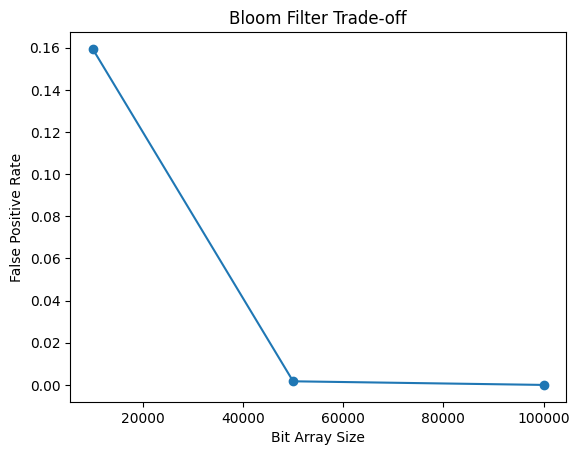

In [37]:
import matplotlib.pyplot as plt

sizes = [r[0] for r in results]
fprs = [r[1] for r in results]

plt.plot(sizes, fprs, marker='o')

plt.xlabel("Bit Array Size")
plt.ylabel("False Positive Rate")
plt.title("Bloom Filter Trade-off")

plt.show()

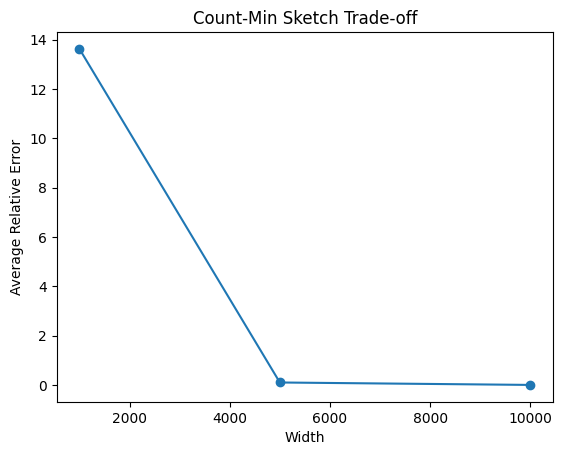

In [38]:
widths = [r[0] for r in results_cms]
errors = [r[1] for r in results_cms]

plt.plot(widths, errors, marker='o')

plt.xlabel("Width")
plt.ylabel("Average Relative Error")
plt.title("Count-Min Sketch Trade-off")

plt.show()